In [157]:
import numpy as np
import pandas as pd
import re

In [158]:
pd.set_option('display.max_colwidth',None)
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)

In [159]:
df=pd.read_csv('gurgaon_properties.csv')

In [160]:
df.head(1)  

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,4 BHK Flat in Sector 85 Gurgaon,flat,ss the leaf,2.2,5641.0,3900.0,Super Built up area 3950(366.97 sq.m.)Built Up area: 3920 sq.ft. (364.18 sq.m.)Carpet area: 3900 sq.ft. (362.32 sq.m.),4,6,3,servant room,"Vvvvvvvv, Sector 85 Gurgaon, Gurgaon, Haryana",10.0,North-West,1 to 5 Year Old,"['Sapphire 83 Mall', 'Dwarka Expressway', 'Central Peripheral Road', 'NH 08', 'Pataudi Road', 'Delhi Public School Sector 84', 'DPG Institute of Technology', 'Genesis Hospital Sector 84', 'Indira Gandhi International Airport', 'Imt Manesar', 'Holiday Inn Hotel Sector 90', 'SkyJumper Trampoline Park', 'Nakhrola Stadium Sector 81A']","Check out this 4 bhk apartment for sale in ss the leaf, a popular residential project that houses in-Demand flats in sector 85 gurgaon. This property faces the north-West direction. The flat is over 3950 sq.Ft. Super built up area and comes with 4 bedroom(s), 6 bathrooms and 3 balconies. The property is located on the 10th floor of a 26 floors tall building. As the project is already ready to move, so you can easily move into this 1-5 years old property. The floor of this flat is beautifully designed using wood flooring, giving the flat an alluring look. Another plus point for this is that it is situated near close to mall, close to highway and close to school. The flat will offer a modern lifestyle as it is presented with many of the amenities such as maintenance staff, visitor parking, park, lift(s), water softening plant, shopping centre, fitness centre / gym, swimming pool, club house / community center and security personnel. The project provides access to clean water through municipal corporation and borewell/tank supply.\n Additional details :Piped gas facility is available in the property.\nThe apartment has borings water supply.\nDaily needs shopping could be done within the society premises to make the stay convinent.\nFull power backup is available.\nThere is also a separate washroom for domestic help.\nThe society has dedicated security guards for every tower.","['5 Fan', '6 Light', '4 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']","['Green Area4.5 out of 5', 'Construction4.5 out of 5', 'Management4 out of 5', 'Amenities4 out of 5', 'Connectivity4.5 out of 5']"


In [161]:
df[['area','areaWithType']].sample(5)   #area with type is not reliable

,area,areaWithType
2611,1790.0,Super Built up area 1790(166.3 sq.m.)
3413,525.0,Carpet area: 525 (48.77 sq.m.)
2087,1325.0,Super Built up area 1325(123.1 sq.m.)Carpet area: 865 sq.ft. (80.36 sq.m.)
832,998.0,Carpet area: 998 (92.72 sq.m.)
1095,2537.0,Carpet area: 2537 (235.7 sq.m.)


# areaWithType

In [162]:
# this function extracts the super built up area
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)',text)
    if match :
        return float(match.group(1))
    return None

In [163]:
# this function extracts the built up area or carpet area 
def get_area(text,area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)',text)
    if match :
        return float(match.group(1))
    return None

In [164]:
# this function checks if the area is provided in sq.m. and converts it to sqft if needed
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value),text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value*10.7639  # conversion factor from sq.m. to sqft
    return area_value    

In [165]:
# extract super built up area and convert to sqft if needed 
df['Super_Built_up_area']=df['areaWithType'].apply(get_super_built_up_area)
df['Super_Built_up_area']=df.apply(lambda x: convert_to_sqft(x['areaWithType'],x['Super_Built_up_area']), axis=1)

#extract built up area and convert to sqft if needed
df['built_up_area']=df['areaWithType'].apply(lambda x: get_area(x,'Built Up area'))
df['built_up_area']=df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']),axis=1)

#extract carpet area and convert to sqft if needed
df['carpet_area']=df['areaWithType'].apply(lambda x: get_area(x,'Carpet area'))
df['carpet_area']=df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']),axis=1)

In [166]:
df[['price','property_type','area','areaWithType','Super_Built_up_area','built_up_area','carpet_area']].sample(10)

,price,property_type,area,areaWithType,Super_Built_up_area,built_up_area,carpet_area
108,0.28,flat,489.0,Carpet area: 489 (45.43 sq.m.),NaN,NaN,489.00000
1240,1.80,flat,2320.0,Carpet area: 2320 (215.54 sq.m.),NaN,NaN,2320.00000
39,0.24,flat,340.0,Carpet area: 340.09 (31.6 sq.m.),NaN,NaN,340.13924
2478,0.71,flat,1171.0,Super Built up area 1295(120.31 sq.m.)Carpet area: 1250 sq.ft. (116.13 sq.m.),1295.0,NaN,1250.00000
1787,2.35,flat,1650.0,Carpet area: 1650 (153.29 sq.m.),NaN,NaN,1650.00000
1008,0.46,flat,950.0,Super Built up area 950(88.26 sq.m.)Built Up area: 800 sq.ft. (74.32 sq.m.)Carpet area: 700 sq.ft. (65.03 sq.m.),950.0,800.0,700.00000
3813,1.35,flat,1850.0,Super Built up area 2355(218.79 sq.m.)Built Up area: 2100 sq.ft. (195.1 sq.m.)Carpet area: 1850 sq.ft. (171.87 sq.m.),2355.0,2100.0,1850.00000
1176,1.43,flat,1609.0,Super Built up area 1608(149.39 sq.m.),1608.0,NaN,NaN
1329,0.65,flat,1365.0,Super Built up area 1365(126.81 sq.m.),1365.0,NaN,NaN
256,2.79,flat,1975.0,Carpet area: 1975 (183.48 sq.m.),NaN,NaN,1975.00000


In [167]:
df[~((df['Super_Built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price', 'property_type','area','areaWithType','Super_Built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,Super_Built_up_area,built_up_area,carpet_area
2571,1.20,flat,1735.0,Super Built up area 1735(161.19 sq.m.)Built Up area: 1635 sq.ft. (151.9 sq.m.)Carpet area: 1535 sq.ft. (142.61 sq.m.),1735.0,1635.0,1535.0
1414,1.22,flat,1700.0,Super Built up area 2300(213.68 sq.m.)Built Up area: 2000 sq.ft. (185.81 sq.m.)Carpet area: 1700 sq.ft. (157.94 sq.m.),2300.0,2000.0,1700.0
707,1.56,flat,1929.0,Super Built up area 1929(179.21 sq.m.)Built Up area: 1580 sq.ft. (146.79 sq.m.)Carpet area: 1450 sq.ft. (134.71 sq.m.),1929.0,1580.0,1450.0
2302,1.25,flat,1760.0,Super Built up area 1760(163.51 sq.m.)Built Up area: 1186 sq.ft. (110.18 sq.m.)Carpet area: 1130 sq.ft. (104.98 sq.m.),1760.0,1186.0,1130.0
360,0.75,flat,1342.0,Super Built up area 1342(124.68 sq.m.)Built Up area: 1180 sq.ft. (109.63 sq.m.)Carpet area: 1050 sq.ft. (97.55 sq.m.),1342.0,1180.0,1050.0


In [168]:
df[~((df['Super_Built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price', 'property_type','area','areaWithType','Super_Built_up_area','built_up_area','carpet_area']].shape

(537, 7)

In [169]:
df[df['areaWithType'].str.contains('Plot')][['price', 'property_type','area','areaWithType','Super_Built_up_area','built_up_area','carpet_area']].shape

(767, 7)

In [170]:
df.isnull().sum()  #finding missing values for all three areas seprately

property_name             0
property_type             0
society                   1
price                    20
price_per_sqft           20
area                     20
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
address                  11
floorNum                 21
facing                 1177
agePossession             1
nearbyLocations         207
description               0
furnishDetails         1032
features                709
rating                  450
Super_Built_up_area    2027
built_up_area          2728
carpet_area            1958
dtype: int64

In [171]:
all_nan_df=df[((df['Super_Built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price', 'property_type','area','areaWithType','Super_Built_up_area','built_up_area','carpet_area']]

In [172]:
all_nan_df.head()

,price,property_type,area,areaWithType,Super_Built_up_area,built_up_area,carpet_area
1,4.70,house,2610.0,Plot area 290(242.48 sq.m.),NaN,NaN,NaN
7,9.00,house,4680.0,Plot area 520(434.79 sq.m.),NaN,NaN,NaN
17,6.00,house,2700.0,Plot area 300(250.84 sq.m.),NaN,NaN,NaN
21,8.50,house,3240.0,Plot area 360(301.01 sq.m.),NaN,NaN,NaN
32,0.85,house,954.0,Plot area 106(88.63 sq.m.),NaN,NaN,NaN


In [173]:
# function to extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(
        r'plot area\s*(\d+\.?\d*)',
        area_with_type,
        re.IGNORECASE
    )
    return float(match.group(1)) if match else None



    

In [174]:
all_nan_df['built_up_area']=all_nan_df['areaWithType'].apply(extract_plot_area)  #update the original dataframe
                                                                                # gurgaon_properties.update(filtered_rows)

In [175]:
all_nan_df.head()

,price,property_type,area,areaWithType,Super_Built_up_area,built_up_area,carpet_area
1,4.70,house,2610.0,Plot area 290(242.48 sq.m.),NaN,290.0,NaN
7,9.00,house,4680.0,Plot area 520(434.79 sq.m.),NaN,520.0,NaN
17,6.00,house,2700.0,Plot area 300(250.84 sq.m.),NaN,300.0,NaN
21,8.50,house,3240.0,Plot area 360(301.01 sq.m.),NaN,360.0,NaN
32,0.85,house,954.0,Plot area 106(88.63 sq.m.),NaN,106.0,NaN


In [176]:
 # 9*sq yard-> sq ft 
 # 10.7*sq.m -> sq ft

In [177]:
# to convert yard and sq m to sq ft
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:  # value is in yard
            return row['built_up_area']*9
        elif round(row['area']/row['built_up_area'])== 11.0: # value is in sq m
            return row['built_up_area']*10.7
        else:
            return row['built_up_area']

In [178]:
all_nan_df['built_up_area']=all_nan_df.apply(convert_scale, axis=1)

In [179]:
all_nan_df

,price,property_type,area,areaWithType,Super_Built_up_area,built_up_area,carpet_area
1,4.70,house,2610.0,Plot area 290(242.48 sq.m.),NaN,2610.00,NaN
7,9.00,house,4680.0,Plot area 520(434.79 sq.m.),NaN,4680.00,NaN
17,6.00,house,2700.0,Plot area 300(250.84 sq.m.),NaN,2700.00,NaN
21,8.50,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.00,NaN
32,0.85,house,954.0,Plot area 106(88.63 sq.m.),NaN,954.00,NaN
34,1.25,house,82781.0,Plot area 115(7692.86 sq.m.),NaN,115.00,NaN
36,12.00,house,3150.0,Plot area 350(292.64 sq.m.),NaN,3150.00,NaN
37,5.88,house,2160.0,Plot area 240(200.67 sq.m.),NaN,2160.00,NaN
40,0.27,house,225.0,Plot area 225(20.9 sq.m.),NaN,225.00,NaN
60,10.50,house,402.0,Plot area 402(37.35 sq.m.),NaN,402.00,NaN


In [180]:
# update the original dataframe
df.update(all_nan_df)

In [181]:
df.isnull().sum()

property_name             0
property_type             0
society                   1
price                    20
price_per_sqft           20
area                     20
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
address                  11
floorNum                 21
facing                 1177
agePossession             1
nearbyLocations         207
description               0
furnishDetails         1032
features                709
rating                  450
Super_Built_up_area    2027
built_up_area          2113
carpet_area            1958
dtype: int64

In [182]:
df.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating,Super_Built_up_area,built_up_area,carpet_area
0,4 BHK Flat in Sector 85 Gurgaon,flat,ss the leaf,2.20,5641.0,3900.0,Super Built up area 3950(366.97 sq.m.)Built Up area: 3920 sq.ft. (364.18 sq.m.)Carpet area: 3900 sq.ft. (362.32 sq.m.),4,6,3,servant room,"Vvvvvvvv, Sector 85 Gurgaon, Gurgaon, Haryana",10.0,North-West,1 to 5 Year Old,"['Sapphire 83 Mall', 'Dwarka Expressway', 'Central Peripheral Road', 'NH 08', 'Pataudi Road', 'Delhi Public School Sector 84', 'DPG Institute of Technology', 'Genesis Hospital Sector 84', 'Indira Gandhi International Airport', 'Imt Manesar', 'Holiday Inn Hotel Sector 90', 'SkyJumper Trampoline Park', 'Nakhrola Stadium Sector 81A']","Check out this 4 bhk apartment for sale in ss the leaf, a popular residential project that houses in-Demand flats in sector 85 gurgaon. This property faces the north-West direction. The flat is over 3950 sq.Ft. Super built up area and comes with 4 bedroom(s), 6 bathrooms and 3 balconies. The property is located on the 10th floor of a 26 floors tall building. As the project is already ready to move, so you can easily move into this 1-5 years old property. The floor of this flat is beautifully designed using wood flooring, giving the flat an alluring look. Another plus point for this is that it is situated near close to mall, close to highway and close to school. The flat will offer a modern lifestyle as it is presented with many of the amenities such as maintenance staff, visitor parking, park, lift(s), water softening plant, shopping centre, fitness centre / gym, swimming pool, club house / community center and security personnel. The project provides access to clean water through municipal corporation and borewell/tank supply.\n Additional details :Piped gas facility is available in the property.\nThe apartment has borings water supply.\nDaily needs shopping could be done within the society premises to make the stay convinent.\nFull power backup is available.\nThere is also a separate washroom for domestic help.\nThe society has dedicated security guards for every tower.","['5 Fan', '6 Light', '4 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']","['Green Area4.5 out of 5', 'Construction4.5 out of 5', 'Management4 out of 5', 'Amenities4 out of 5', 'Connectivity4.5 out of 5']",3950.0,3920.0,3900.0
1,4 Bedroom House for sale in Sector 70A Gurgaon,house,bptp visionnaire,4.70,18008.0,2610.0,Plot area 290(242.48 sq.m.),4,4,3+,others,"B- 186, Sector 70A Gurgaon, Gurgaon, Haryana",3.0,North-East,0 to 1 Year Old,"['Good Earth City Center 2', 'Kunskapsskolan International School', 'Peace Taekwondo Academy', 'Rama krishna public school', 'Suraj School Sector 75', 'Axis Bank ATM, Sector 57', 'Sparsh Hospital, Sohna Rd', 'Oriental Bank of Commerce Palra Rd', 'The Federal Bank Ltd Palra', 'HDFC Bank Darbaripur Rd', 'Central Bank Of IndiaSohna Rd', 'Tata Projects Limited', 'IndianOil, Hasanpur', 'HPCL Sadhuram &

# additionalroom

In [183]:
df['additionalRoom'].value_counts()   # there are five types of additional rooms

additionalRoom
not available                                    1691
servant room                                      710
study room                                        251
others                                            237
pooja room                                        170
store room                                        107
study room,servant room                           100
pooja room,servant room                            84
pooja room,study room,servant room,store room      72
servant room,others                                60
pooja room,study room,servant room,others          57
pooja room,study room,servant room                 57
servant room,pooja room                            38
servant room,store room                            34
study room,others                                  30
pooja room,study room                              24
pooja room,store room                              17
pooja room,others                                  17
servant room,

In [184]:
# list of new columns to be created
new_cols=['study room', 'servent room','store room','pooja room','others']

# popullate the new columns based on the "additionalRoom" columns
for col in new_cols:
    df[col]=df['additionalRoom'].str.contains(col).astype(int)

In [185]:
df.sample(5)[['additionalRoom', 'study room', 'servent room','store room','pooja room','others']]

,additionalRoom,study room,servent room,store room,pooja room,others
98,not available,0,0,0,0,0
1383,not available,0,0,0,0,0
3406,others,0,0,0,0,1
2865,servant room,0,0,0,0,0
65,not available,0,0,0,0,0


In [186]:
df.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating,Super_Built_up_area,built_up_area,carpet_area,study room,servent room,store room,pooja room,others
0,4 BHK Flat in Sector 85 Gurgaon,flat,ss the leaf,2.20,5641.0,3900.0,Super Built up area 3950(366.97 sq.m.)Built Up area: 3920 sq.ft. (364.18 sq.m.)Carpet area: 3900 sq.ft. (362.32 sq.m.),4,6,3,servant room,"Vvvvvvvv, Sector 85 Gurgaon, Gurgaon, Haryana",10.0,North-West,1 to 5 Year Old,"['Sapphire 83 Mall', 'Dwarka Expressway', 'Central Peripheral Road', 'NH 08', 'Pataudi Road', 'Delhi Public School Sector 84', 'DPG Institute of Technology', 'Genesis Hospital Sector 84', 'Indira Gandhi International Airport', 'Imt Manesar', 'Holiday Inn Hotel Sector 90', 'SkyJumper Trampoline Park', 'Nakhrola Stadium Sector 81A']","Check out this 4 bhk apartment for sale in ss the leaf, a popular residential project that houses in-Demand flats in sector 85 gurgaon. This property faces the north-West direction. The flat is over 3950 sq.Ft. Super built up area and comes with 4 bedroom(s), 6 bathrooms and 3 balconies. The property is located on the 10th floor of a 26 floors tall building. As the project is already ready to move, so you can easily move into this 1-5 years old property. The floor of this flat is beautifully designed using wood flooring, giving the flat an alluring look. Another plus point for this is that it is situated near close to mall, close to highway and close to school. The flat will offer a modern lifestyle as it is presented with many of the amenities such as maintenance staff, visitor parking, park, lift(s), water softening plant, shopping centre, fitness centre / gym, swimming pool, club house / community center and security personnel. The project provides access to clean water through municipal corporation and borewell/tank supply.\n Additional details :Piped gas facility is available in the property.\nThe apartment has borings water supply.\nDaily needs shopping could be done within the society premises to make the stay convinent.\nFull power backup is available.\nThere is also a separate washroom for domestic help.\nThe society has dedicated security guards for every tower.","['5 Fan', '6 Light', '4 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']","['Green Area4.5 out of 5', 'Construction4.5 out of 5', 'Management4 out of 5', 'Amenities4 out of 5', 'Connectivity4.5 out of 5']",3950.0,3920.0,3900.0,0,0,0,0,0
1,4 Bedroom House for sale in Sector 70A Gurgaon,house,bptp visionnaire,4.70,18008.0,2610.0,Plot area 290(242.48 sq.m.),4,4,3+,others,"B- 186, Sector 70A Gurgaon, Gurgaon, Haryana",3.0,North-East,0 to 1 Year Old,"['Good Earth City Center 2', 'Kunskapsskolan International School', 'Peace Taekwondo Academy', 'Rama krishna public school', 'Suraj School Sector 75', 'Axis Bank ATM, Sector 57', 'Sparsh Hospital, Sohna Rd', 'Oriental Bank of Commerce Palra Rd', 'The Federal Bank Ltd Palra', 'HDFC Bank Darbaripur Rd', 'Central Bank Of IndiaSohna Rd', '

# agePossession

In [187]:
original = pd.read_csv('gurgaon_properties.csv', usecols=['agePossession'])

In [188]:
df['agePossession'] = original['agePossession']

In [189]:
df['agePossession'].value_counts(dropna=False)

agePossession
1 to 5 Year Old       1705
5 to 10 Year Old       610
0 to 1 Year Old        551
undefined              358
10+ Year Old           353
Under Construction      92
Within 6 months         70
Within 3 months         26
Dec 2023                22
By 2023                 19
By 2024                 17
Dec 2024                16
Mar 2024                14
Jan 2024                 8
Oct 2024                 8
Jun 2024                 7
Dec 2025                 7
Aug 2023                 7
Aug 2024                 5
Nov 2023                 5
Jul 2024                 4
Sep 2023                 4
Jan 2025                 4
Oct 2023                 4
By 2025                  4
Feb 2024                 3
Nov 2024                 3
May 2024                 3
Jul 2027                 2
Jun 2027                 2
Sep 2025                 2
By 2027                  2
Mar 2025                 2
Jan 2026                 2
Aug 2025                 2
Dec 2026                 2
Jul 2025      

In [190]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or " Within 6 months" in value or " Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # for entries like 'may 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [191]:
df['age_category'] = df['agePossession'].apply(categorize_age_possession)

In [192]:
df['age_category'].value_counts()

age_category
Relatively New        1705
Moderately Old         610
New Property           551
Undefined              455
Old Property           353
Under Construction     287
Name: count, dtype: int64

In [193]:
df.head()


,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating,Super_Built_up_area,built_up_area,carpet_area,study room,servent room,store room,pooja room,others,age_category
0,4 BHK Flat in Sector 85 Gurgaon,flat,ss the leaf,2.20,5641.0,3900.0,Super Built up area 3950(366.97 sq.m.)Built Up area: 3920 sq.ft. (364.18 sq.m.)Carpet area: 3900 sq.ft. (362.32 sq.m.),4,6,3,servant room,"Vvvvvvvv, Sector 85 Gurgaon, Gurgaon, Haryana",10.0,North-West,1 to 5 Year Old,"['Sapphire 83 Mall', 'Dwarka Expressway', 'Central Peripheral Road', 'NH 08', 'Pataudi Road', 'Delhi Public School Sector 84', 'DPG Institute of Technology', 'Genesis Hospital Sector 84', 'Indira Gandhi International Airport', 'Imt Manesar', 'Holiday Inn Hotel Sector 90', 'SkyJumper Trampoline Park', 'Nakhrola Stadium Sector 81A']","Check out this 4 bhk apartment for sale in ss the leaf, a popular residential project that houses in-Demand flats in sector 85 gurgaon. This property faces the north-West direction. The flat is over 3950 sq.Ft. Super built up area and comes with 4 bedroom(s), 6 bathrooms and 3 balconies. The property is located on the 10th floor of a 26 floors tall building. As the project is already ready to move, so you can easily move into this 1-5 years old property. The floor of this flat is beautifully designed using wood flooring, giving the flat an alluring look. Another plus point for this is that it is situated near close to mall, close to highway and close to school. The flat will offer a modern lifestyle as it is presented with many of the amenities such as maintenance staff, visitor parking, park, lift(s), water softening plant, shopping centre, fitness centre / gym, swimming pool, club house / community center and security personnel. The project provides access to clean water through municipal corporation and borewell/tank supply.\n Additional details :Piped gas facility is available in the property.\nThe apartment has borings water supply.\nDaily needs shopping could be done within the society premises to make the stay convinent.\nFull power backup is available.\nThere is also a separate washroom for domestic help.\nThe society has dedicated security guards for every tower.","['5 Fan', '6 Light', '4 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']","['Green Area4.5 out of 5', 'Construction4.5 out of 5', 'Management4 out of 5', 'Amenities4 out of 5', 'Connectivity4.5 out of 5']",3950.0,3920.0,3900.0,0,0,0,0,0,Relatively New
1,4 Bedroom House for sale in Sector 70A Gurgaon,house,bptp visionnaire,4.70,18008.0,2610.0,Plot area 290(242.48 sq.m.),4,4,3+,others,"B- 186, Sector 70A Gurgaon, Gurgaon, Haryana",3.0,North-East,0 to 1 Year Old,"['Good Earth City Center 2', 'Kunskapsskolan International School', 'Peace Taekwondo Academy', 'Rama krishna public school', 'Suraj School Sector 75', 'Axis Bank ATM, Sector 57', 'Sparsh Hospital, Sohna Rd', 'Oriental Bank of Commerce Palra Rd', 'The Federal Bank Ltd Palra', 'HDFC Bank Darbaripur Rd', 'Centr

# furnishDetails

In [195]:
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
598,[],"['Power Back-up', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'No open drainage around', 'Visitor Parking', 'Swimming Pool', 'Park', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Club house / Community Center', 'Water softening plant']"
526,"['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",NaN
849,NaN,"['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
2272,"['4 Wardrobe', '7 Fan', '3 Geyser', '11 Light', '4 AC', '1 Modular Kitchen', '1 Chimney', '2 Curtains', 'No Bed', 'No Dining Table', 'No Exhaust Fan', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
645,"['1 Wardrobe', '2 Fan', '1 Sofa', '1 Exhaust Fan', '1 Geyser', '2 Light', '1 Chimney', '1 Modular Kitchen', '1 Curtains', '1 AC', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'Piped-gas', 'Internet/wi-fi connectivity', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"


In [196]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []

for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)

unique_furnishings = list(set(all_furnishings))


# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0

        pattern = re.compile(f"(\\d+) {furnishing}")
        match = pattern.search(details)

        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1

    return 0


# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [
    re.sub(r'No |\d+', '', furnishing).strip()
    for furnishing in unique_furnishings
]

columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [
    furnishing for furnishing in columns_to_include if furnishing
]  # Remove empty strings


# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(
        lambda x: get_furnishing_count(x, furnishing)
    )


# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

In [197]:
furnishings_df.shape

(3961, 19)

In [198]:
furnishings_df.drop(columns=['furnishDetails'],inplace =True)

C:\Users\farman ahmad\AppData\Local\Temp\ipykernel_16560\511112996.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace =True)


In [200]:
furnishings_df.sample(5)

,Light,Modular Kitchen,TV,Exhaust Fan,Fridge,Dining Table,Geyser,Fan,Chimney,Microwave,AC,Sofa,Bed,Water Purifier,Washing Machine,Stove,Wardrobe,Curtains
160,0,1,0,0,0,0,0,0,1,0,4,0,0,0,0,0,3,0
3958,0,1,0,1,0,0,0,0,0,0,3,0,0,0,0,0,0,0
3679,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2749,10,1,0,1,0,0,3,6,1,0,0,0,0,0,0,0,2,0
797,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [210]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [211]:
scaler=StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [212]:
wcss_reduced=[]

for i in range(1,11):
    kmeans =KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

C:\Users\farman ahmad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=16.
  warnings.warn(
C:\Users\farman ahmad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=16.
  warnings.warn(
C:\Users\farman ahmad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=16.
  warnings.warn(
C:\Users\farman ahmad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known 

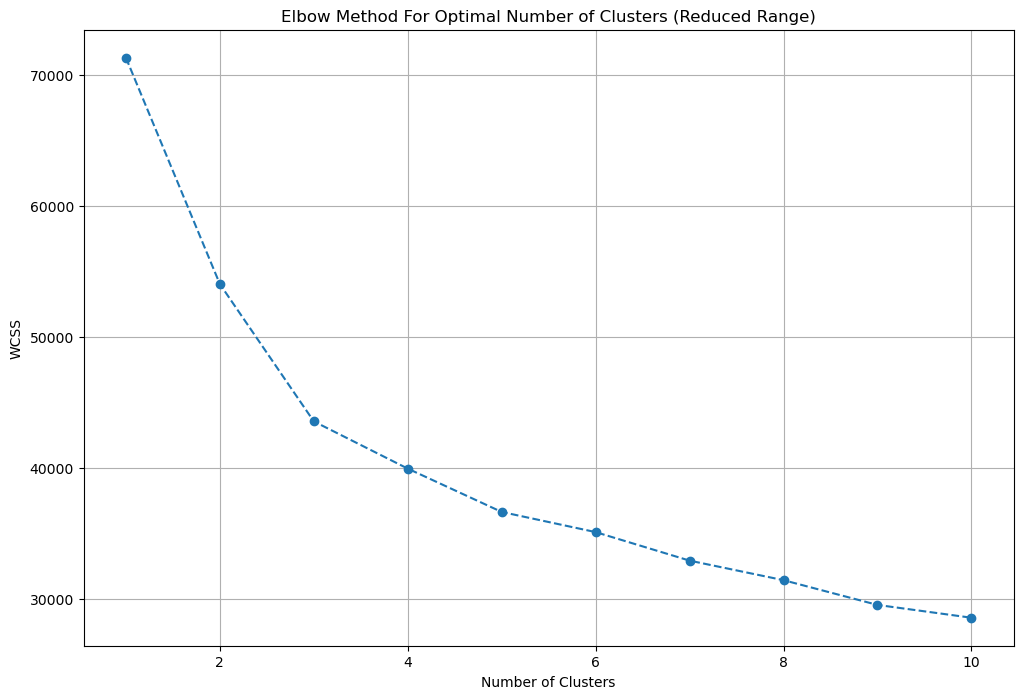

In [213]:
#plot the result
plt.figure(figsize=(12,8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [215]:
n_clusters= 3

#fit the KMeans model
kmeans= KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

#predict the cluster asssignment for each row
cluster_assignments=kmeans.predict(scaled_data)

C:\Users\farman ahmad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=16.
  warnings.warn(


In [216]:
df=df.iloc[:,:-18]

In [217]:
df['furnishing_type']=cluster_assignments

In [227]:
df.sample(5)[['furnishDetails','furnishing_type']]

#0-> unfurnished
# 1-> semifurnished
# 2-> furnished

,furnishDetails,furnishing_type
382,"['1 Wardrobe', '1 Fan', '1 Light', '1 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",0
3118,[],0
519,NaN,0
316,"['5 Fan', '1 Exhaust Fan', '1 Geyser', '10 Light', '5 Curtains', '1 Modular Kitchen', '3 Wardrobe', 'No AC', 'No Bed', 'No Chimney', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",2
3710,NaN,0


# features

In [228]:
df[['society','features']].sample(5)

,society,features
554,raheja navodaya,NaN
3112,godrej aria,"['Power Back-up', 'Intercom Facility', 'Lift(s)', 'Swimming Pool', 'Maintenance Staff', 'Park', 'Security Personnel', 'Fitness Centre / GYM', 'Club house / Community Center', 'Rain Water Harvesting']"
1309,godrej nature plus,"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Shopping Centre', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center']"
3590,emaar mgf the palm drive,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"
1059,silverglades tarudhan valley golf resort,"['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Fitness Centre / GYM', 'Club house / Community Center']"


In [229]:
df['features'].isnull().sum()


np.int64(709)

In [230]:
import pandas as pd
app_df = pd.read_csv('appartments.csv')
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"


In [231]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [232]:
temp_df = df[df['features'].isnull()]

In [233]:
temp_df.shape

(709, 30)

In [235]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [236]:
df.loc[temp_df.index,'features'] = x.values

In [237]:
df['features'].isnull().sum()

np.int64(552)

In [238]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [239]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [240]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Beach Volley Ball Court,Billiards,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Car wash area,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Party Lawn,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Solar Water Heating,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Theatre,Toddler Pool,Valet Parking,Vastu Compliant,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
3590,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,0
1970,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,1,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,1,0,0
1326,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2637,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,1,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
544,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0


In [241]:
features_binary_df.shape

(3961, 130)

In [242]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

C:\Users\farman ahmad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=16.
  warnings.warn(
C:\Users\farman ahmad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=16.
  warnings.warn(
C:\Users\farman ahmad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=16.
  warnings.warn(
C:\Users\farman ahmad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known 

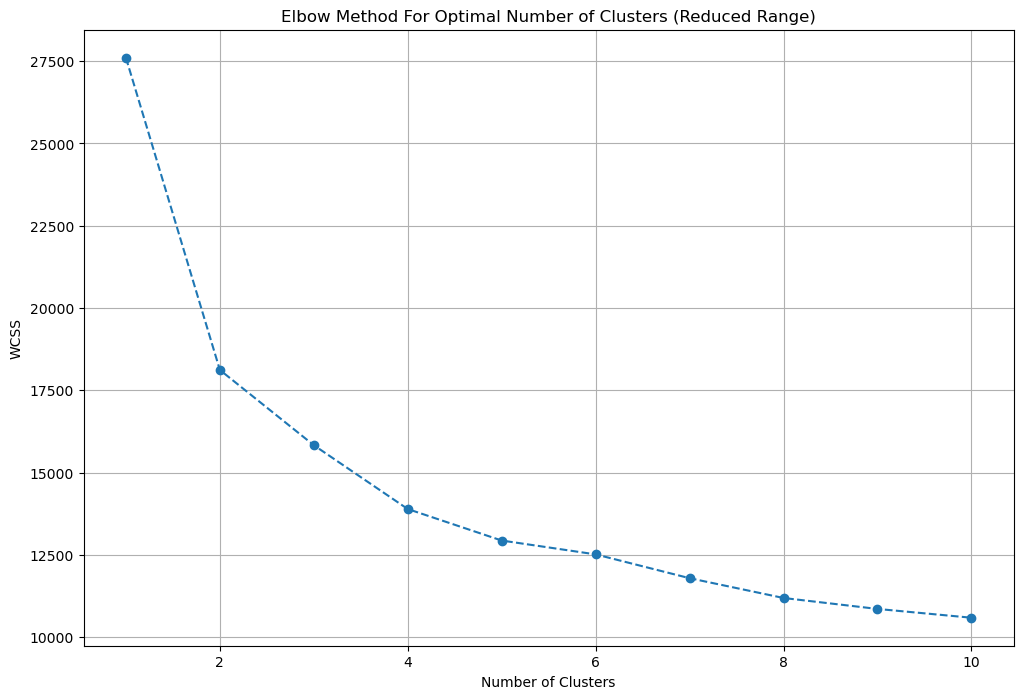

In [243]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [244]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)

In [245]:
df['luxury_score'] = luxury_score

In [246]:
df.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating,Super_Built_up_area,built_up_area,carpet_area,study room,servent room,store room,pooja room,others,age_category,furnishing_type,features_list,luxury_score
0,4 BHK Flat in Sector 85 Gurgaon,flat,ss the leaf,2.20,5641.0,3900.0,Super Built up area 3950(366.97 sq.m.)Built Up area: 3920 sq.ft. (364.18 sq.m.)Carpet area: 3900 sq.ft. (362.32 sq.m.),4,6,3,servant room,"Vvvvvvvv, Sector 85 Gurgaon, Gurgaon, Haryana",10.0,North-West,1 to 5 Year Old,"['Sapphire 83 Mall', 'Dwarka Expressway', 'Central Peripheral Road', 'NH 08', 'Pataudi Road', 'Delhi Public School Sector 84', 'DPG Institute of Technology', 'Genesis Hospital Sector 84', 'Indira Gandhi International Airport', 'Imt Manesar', 'Holiday Inn Hotel Sector 90', 'SkyJumper Trampoline Park', 'Nakhrola Stadium Sector 81A']","Check out this 4 bhk apartment for sale in ss the leaf, a popular residential project that houses in-Demand flats in sector 85 gurgaon. This property faces the north-West direction. The flat is over 3950 sq.Ft. Super built up area and comes with 4 bedroom(s), 6 bathrooms and 3 balconies. The property is located on the 10th floor of a 26 floors tall building. As the project is already ready to move, so you can easily move into this 1-5 years old property. The floor of this flat is beautifully designed using wood flooring, giving the flat an alluring look. Another plus point for this is that it is situated near close to mall, close to highway and close to school. The flat will offer a modern lifestyle as it is presented with many of the amenities such as maintenance staff, visitor parking, park, lift(s), water softening plant, shopping centre, fitness centre / gym, swimming pool, club house / community center and security personnel. The project provides access to clean water through municipal corporation and borewell/tank supply.\n Additional details :Piped gas facility is available in the property.\nThe apartment has borings water supply.\nDaily needs shopping could be done within the society premises to make the stay convinent.\nFull power backup is available.\nThere is also a separate washroom for domestic help.\nThe society has dedicated security guards for every tower.","['5 Fan', '6 Light', '4 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']","['Green Area4.5 out of 5', 'Construction4.5 out of 5', 'Management4 out of 5', 'Amenities4 out of 5', 'Connectivity4.5 out of 5']",3950.0,3920.0,3900.0,0,0,0,0,0,Relatively New,0,"[Centrally Air Conditioned, Water purifier, Security / Fire Alarm, Feng Shui / Vaastu Compliant, Private Garden / Terrace, Intercom Facility, Lift(s), High Ceiling Height, Maintenance Staff, False Ceiling Lighting, Water Storage, Separate entry for servant room, No open drainage around, Bank Attached Property, Piped-gas, Internet/wi-fi connectivity, Recently Renovated, Visitor Parking, Swimming Pool, Park, Security Personnel, Natural Light, Airy Rooms, Spacious Interiors,

In [247]:
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [248]:
df.sample(5)

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,address,floorNum,facing,agePossession,description,rating,Super_Built_up_area,built_up_area,carpet_area,study room,servent room,store room,pooja room,others,age_category,furnishing_type,luxury_score
3143,2 BHK Flat in Sector 107 Gurgaon,flat,signature global solera,0.28,5674.0,493.0,Carpet area: 489 (45.43 sq.m.),2,2,2,"Sector 107 Gurgaon, Gurgaon, Haryana",6.0,West,1 to 5 Year Old,"This lovely 2 bhk apartment/flat in sector 107 gurgaon is available for sale in one of gurgaon's most popular projects, signature global solera. This is a west-Facing property. The flat occupies a carpet area of 489 sq.Ft. That consists of 2 bedrooms, 2 bathrooms and 2 balconies. The flat has a total of 14 floors and this property is situated on 6th floor. As the project is already ready to move, so you can easily move into this 1-5 years old property. The beautifully designed vitrified flooring enhances the beauty of the flat. The flat will offer a modern lifestyle as it is presented with many of the amenities such as fitness centre / gym, park, lift(s) and maintenance staff. The society provides continuous water supply from municipal corporation.\n Additional details :The apartment has borings water supply.\nDaily needs shopping could be done within the society premises to make the stay convinent.\nFull power backup is available.\nThe society has dedicated security guards for every tower.","['Green Area4.5 out of 5', 'Construction4.5 out of 5', 'Management4 out of 5', 'Amenities4 out of 5', 'Connectivity3 out of 5']",NaN,NaN,489.0,0,0,0,0,0,Relatively New,0,45
369,6 Bedroom House for sale in Bhim Nagar,house,independent,1.00,41666.0,240.0,Built Up area: 240 (22.3 sq.m.),6,4,0,"Bhim Nagar, Sector 6, Bhim Nagar, Gurgaon, Haryana",3.0,NaN,undefined,Best in class property available at bhim nagar location in gurgaon,"['Environment3 out of 5', 'Lifestyle4 out of 5', 'Connectivity5 out of 5', 'Safety4 out of 5']",NaN,240.0,NaN,0,0,0,0,0,Undefined,0,0
1667,3 BHK Flat in Sector 104 Gurgaon,flat,ats triumph,1.95,8515.0,2290.0,Carpet area: 2290 (212.75 sq.m.),3,3,3+,"3042, Sector 104 Gurgaon, Gurgaon, Haryana",3.0,NaN,0 to 1 Year Old,Completely new unused and finished as per builder specifications,"['Management5 out of 5', 'Green Area4 out of 5', 'Construction5 out of 5', 'Amenities4.5 out of 5', 'Connectivity5 out of 5']",NaN,NaN,2290.0,0,0,0,0,0,New Property,0,69
2986,5 Bedroom House for sale in Ravi Nagar,house,independent,0.42,9333.0,450.0,Built Up area: 450 (41.81 sq.m.),5,3,2,"Ravi Nagar, Sector 9, Ravi Nagar, Gurgaon, Haryana",2.0,NaN,undefined,Best in class property available at ravi nagar location in gurgaon,NaN,NaN,450.0,NaN,0,0,0,0,0,Undefined,0,0
3919,2 BHK Flat in Sector 103 Gurgaon,flat,landmark the residency,0.90,6666.0,1350.0,Super Built up area 1350(125.42 sq.m.),2,2,2,"Sector 103 Gurgaon, Gurgaon, Haryana",1.0,South-West,1 to 5 Year Old,"We are the proud owners of this 2 bhk apartment available in , dwarka expressway gurgaon, gurgaon. This it is a and the unit is located on 1st floor and has a super built-Up area of 1350 sq.Ft. . It has 2 bathroom(s) and 2 balcony(s). The unit is located in a co-Operative society.\n Additional details :The apartment has munciple supply water supply.\nDaily needs shopping could be done within the society premises to make the stay convinent.\nNo power backup is available.\nThe society has dedicated security guards for every tower.","['Connectivity4 out of 5', 'Lifestyle4 out of 5', 'Safety4 out of 5', 'Environment4 out of 5']",1350.0,NaN,NaN,0,0,0,0,0,Relatively New,0,44


In [249]:
df.shape

(3961, 27)

In [250]:
df.to_csv('gurgaon_properties_cleaned_v2.csv',index=False)